In [1]:
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt

from phd.config import load_config, copy_config
import phd.models.cm.side_loaded_plate as slp
from phd.io import save_run_data as save_run_data_generic
from phd.io import load_run as load_run_generic

from phd.plot import get_current_config as plt_cfg, book_config, book_compact_config, A4_config, KUL_CYCLE, KUL_COLORS

book_config.set_as_current()
page_width = plt_cfg().page_width

save_fig = True
save_table = True
if save_fig:
    mpl.rcParams["pgf.texsystem"] = "pdflatex"

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for parent in [current, *current.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise FileNotFoundError("Could not find project root (missing pyproject.toml).")

PROJECT_ROOT = find_project_root(Path.cwd())
CHAPTER_DIR = PROJECT_ROOT / "chapters" / "IV_MaterialCharacterization" / "01_side_loaded_plate"
IMAGE_DIR = CHAPTER_DIR / "images"
PGF_DIR = IMAGE_DIR / "pgf"
TABLE_DIR = CHAPTER_DIR / "tables"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
PGF_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_ROOT = PROJECT_ROOT / "results" / "side_loaded_plate"
print(f"Project root: {PROJECT_ROOT}")
print(f"Results root: {RESULTS_ROOT}")

Using backend: jax
Other supported backends: tensorflow.compat.v1, tensorflow, pytorch, paddle.
paddle supports more examples now and is recommended.
Enable just-in-time compilation with XLA.



Project root: /home/r2d2/code/PhD
Results root: /home/r2d2/code/PhD/results/side_loaded_plate


In [2]:
def build_noise_study_cfg(
    seed: int = 0,
    camera: str = "5MP",
    measurement_type: str = "displacement",
    dic_id: int = 1,
    noise: int = 1,
    save_fields: bool = False,
):
    cfg = load_config("side_loaded_plate")

    cfg.seed = seed
    cfg.task.type = "inverse"

    cfg.problem.material.law = "isotropic"
    cfg.problem.geometry.length = 100.0
    cfg.problem.loading.m = 0.3
    cfg.problem.loading.b = 50.0

    cfg.model.net_type = "SPINN"
    cfg.model.formulation = "mixed"
    cfg.model.architecture.n_hidden = 3
    cfg.model.architecture.width = 32
    cfg.model.architecture.rank = 32

    cfg.training.n_iter = 20000
    cfg.training.lr_decay = ["warmup cosine", 1e-4, 5e-3, 1000, 10000, 5e-4]
    cfg.training.log_every = 250
    cfg.training.num_domain = 10000
    cfg.training.lr = 1e-3
    cfg.training.coord_normalization = True
    cfg.training.stress_bc = True
    cfg.training.self_attention.enabled = False
    cfg.training.loss_normalization.scheme = "grad_norm"

    cfg.task.inverse.measurements.source = "dic"
    cfg.task.inverse.measurements.type = measurement_type
    cfg.task.inverse.measurements.dic.path = f"side_loaded_plate/dic/{camera}/{noise}noise"
    cfg.task.inverse.measurements.dic.sample_id = int(dic_id)
    cfg.task.inverse.measurements.noise_ratio = 0.0

    cfg.results.base_dir = str(PROJECT_ROOT / "results")
    cfg.results.save_on_disk = False
    cfg.results.experiment_name = None

    if save_fields:
        cfg.problem.log_fields = ["Ux", "Uy", "Exx", "Eyy", "Exy", "Sxx", "Syy", "Sxy"]
    else:
        cfg.problem.log_fields = []

    return cfg

cfg_preview = build_noise_study_cfg(
    seed=0,
    camera="5MP",
    measurement_type="displacement",
    dic_id=1,
    noise=1,
    save_fields=True,
)
print(f"Model: {cfg_preview.model.net_type} / {cfg_preview.model.formulation}")
print(f"Measurement source: {cfg_preview.task.inverse.measurements.source}")
print(f"Measurement type: {cfg_preview.task.inverse.measurements.type}")
print(f"DIC path: {cfg_preview.task.inverse.measurements.dic.path}")
print(f"DIC sample id: {cfg_preview.task.inverse.measurements.dic.sample_id}")

Model: SPINN / mixed
Measurement source: dic
Measurement type: displacement
DIC path: side_loaded_plate/dic/5MP/1noise
DIC sample id: 1


## 1) DIC noise-study sweep

Run inverse SPINN with DIC measurements across camera resolution, measurement type (`displacement`/`strain`), and DIC sample id (`dic_id`).

In [3]:
# 2) Run/load noise-study cases: camera x measurement type x dic_id
mode = "load"  # "run" or "load"
noise_level = 1

camera_list = ["5MP", "2MP", "0.4MP"]
measurement_types = ["displacement", "strain"]
dic_ids = range(1, 11)

results_by_case = {}
run_dirs_by_case = {}

for camera in camera_list:
    for measurement_type in measurement_types:
        for dic_id in dic_ids:
            run_name = f"noise_study/{noise_level}noise/{camera}/{measurement_type}/dic_{dic_id:02d}"
            save_fields = dic_id == 1 # only save for the first run

            if mode == "run":
                cfg_case = build_noise_study_cfg(
                    seed=0,
                    camera=camera,
                    measurement_type=measurement_type,
                    dic_id=dic_id,
                    noise=noise_level,
                    save_fields=save_fields,
                )
                results_case = slp.train(cfg_case)
                run_dir_case = Path(slp.save_run_data(results_case, run_name=run_name))
            else:
                results_case = slp.load_run(run_name)
                run_dir_case = Path(results_case["run_dir"] )

            case_key = (camera, measurement_type, dic_id)
            results_by_case[case_key] = results_case
            run_dirs_by_case[case_key] = run_dir_case
            print(f"[{mode}] {camera:>4} | {measurement_type:<12} | dic_id={dic_id:02d} -> {run_dir_case}")


W0220 09:36:44.825330 3849951 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0220 09:36:44.828811 3849782 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


[load]  5MP | displacement | dic_id=01 -> /home/r2d2/code/PhD/results/side_loaded_plate/noise_study/1noise/5MP/displacement/dic_01
[load]  5MP | displacement | dic_id=02 -> /home/r2d2/code/PhD/results/side_loaded_plate/noise_study/1noise/5MP/displacement/dic_02
[load]  5MP | displacement | dic_id=03 -> /home/r2d2/code/PhD/results/side_loaded_plate/noise_study/1noise/5MP/displacement/dic_03
[load]  5MP | displacement | dic_id=04 -> /home/r2d2/code/PhD/results/side_loaded_plate/noise_study/1noise/5MP/displacement/dic_04
[load]  5MP | displacement | dic_id=05 -> /home/r2d2/code/PhD/results/side_loaded_plate/noise_study/1noise/5MP/displacement/dic_05
[load]  5MP | displacement | dic_id=06 -> /home/r2d2/code/PhD/results/side_loaded_plate/noise_study/1noise/5MP/displacement/dic_06
[load]  5MP | displacement | dic_id=07 -> /home/r2d2/code/PhD/results/side_loaded_plate/noise_study/1noise/5MP/displacement/dic_07
[load]  5MP | displacement | dic_id=08 -> /home/r2d2/code/PhD/results/side_loaded_p


Plot case: ('5MP', 'displacement', 1) -> /home/r2d2/code/PhD/results/side_loaded_plate/noise_study/1noise/5MP/displacement/dic_01


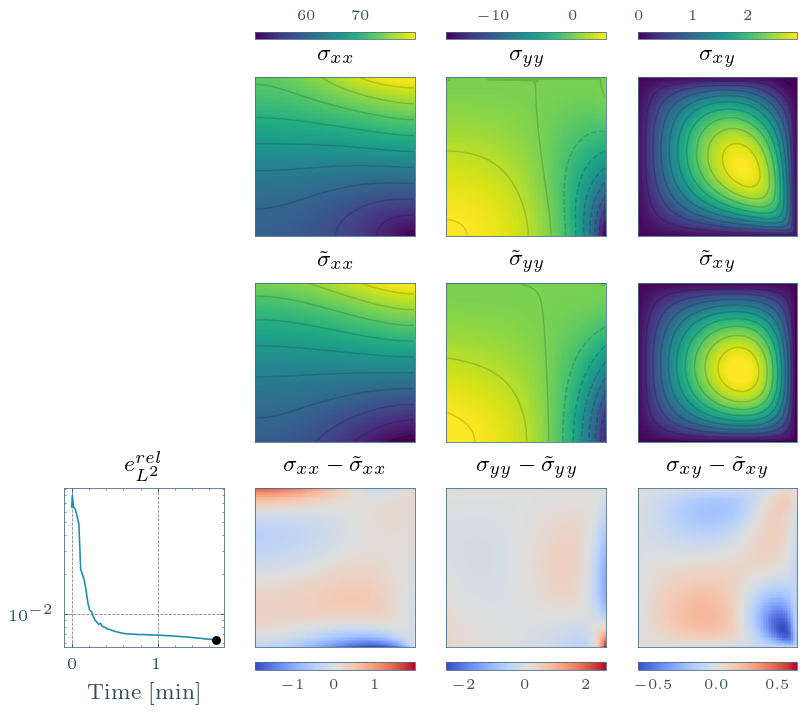

In [5]:
# Keep a representative case for plotting below
plot_case = ("5MP", "displacement", 1)
results_single = results_by_case[plot_case]
single_run_dir = run_dirs_by_case[plot_case]
print(f"\nPlot case: {plot_case} -> {single_run_dir}")

# Plot and save the single-run results (analytical-plate style)
fig, artists = slp.plot_results(
    results_single,
    iteration=-1,
    step_type="time",
    time_unit="min",
    fields=["Sxx", "Syy", "Sxy"],
    plot_contours=True,
    dpi=200,
    show_metrics=True,
    show_residual=True,
    show_iter=False,
    metrics=["L2 Error"],
    side_panel="variables",
)
plt.show()

## 3) Save noise-study summary and statistics

Aggregate all runs by camera resolution and measurement type, then save JSON, LaTeX table, and summary figure.

In [4]:
import json
import numpy as np

NOISE_SUMMARY_PATH = TABLE_DIR / "02_noise_study_stats.json"
E_REF = 210.0
NU_REF = 0.3000

summary_data = {}
if NOISE_SUMMARY_PATH.exists():
    with open(NOISE_SUMMARY_PATH, "r") as json_file:
        summary_data = json.load(json_file)

summary_data.update({
    "E_actual": E_REF,
    "nu_actual": NU_REF,
})

for camera in camera_list:
    camera_block = summary_data.setdefault(camera, {})
    for measurement_type in measurement_types:
        E_samples = []
        nu_samples = []

        for dic_id in dic_ids:
            history = np.array(results_by_case[(camera, measurement_type, dic_id)]["callbacks"]["variable_value"].history)
            E_samples.append(np.mean(history[-10:, 1]) / 1e3)
            nu_samples.append(np.mean(history[-10:, 2]))

        E_samples = np.array(E_samples)
        nu_samples = np.array(nu_samples)

        camera_block[measurement_type] = {
            "E": {
                "mean": float(np.mean(E_samples)),
                "std": float(np.std(E_samples)),
                "mean_rel_error": float(np.mean(np.abs((E_samples - E_REF) / E_REF)) * 100),
                "std_rel_error": float(np.std(np.abs((E_samples - E_REF) / E_REF)) * 100),
            },
            "nu": {
                "mean": float(np.mean(nu_samples)),
                "std": float(np.std(nu_samples)),
                "mean_rel_error": float(np.mean(np.abs((nu_samples - NU_REF) / NU_REF)) * 100),
                "std_rel_error": float(np.std(np.abs((nu_samples - NU_REF) / NU_REF)) * 100),
            },
        }

with open(NOISE_SUMMARY_PATH, "w") as json_file:
    json.dump(summary_data, json_file, indent=4)

print(f"Saved: {NOISE_SUMMARY_PATH}")

Saved: /home/r2d2/code/PhD/chapters/IV_MaterialCharacterization/01_side_loaded_plate/tables/02_noise_study_stats.json


In [5]:
from IPython.display import display
import pandas as pd
from phd.io import save_df_to_latex

NOISE_TABLE_TEX_PATH = TABLE_DIR / "noise_study_stats.tex"

with open(NOISE_SUMMARY_PATH, "r") as f:
    noise_data = json.load(f)

rows = []
for camera in camera_list:
    model_map = [
        ("SPINN-disp", "displacement"),
        ("SPINN-strain", "strain"),
        ("VFM", "VFM"),
    ]
    for model_name, key in model_map:
        if key not in noise_data.get(camera, {}):
            continue
        block = noise_data[camera][key]
        rows.append({
            "Camera": camera,
            "Model": model_name,
            "E (GPa)": float(block["E"]["mean"]),
            "E std (GPa)": float(block["E"]["std"]),
            "E — Error (%)": float(block["E"]["mean_rel_error"]),
            "ν": float(block["nu"]["mean"]),
            "ν std": float(block["nu"]["std"]),
            "ν — Error (%)": float(block["nu"]["mean_rel_error"]),
        })

df_noise_stats = pd.DataFrame(rows)

display(
    df_noise_stats.style
    .format({
        "E (GPa)": "{:.2f}",
        "E std (GPa)": "{:.2f}",
        "E — Error (%)": "{:.2f}",
        "ν": "{:.4f}",
        "ν std": "{:.4f}",
        "ν — Error (%)": "{:.2f}",
    })
    .set_properties(subset=["Camera", "Model"], **{"text-align": "left"})
)

if save_table:
    formatters = {
        "E (GPa)": "{:.2f}",
        "E std (GPa)": "{:.2f}",
        "E — Error (%)": "{:.2f}",
        "ν": "{:.4f}",
        "ν std": "{:.4f}",
        "ν — Error (%)": "{:.2f}",
    }
    save_df_to_latex(df_noise_stats, str(NOISE_TABLE_TEX_PATH), formatters=formatters)
    print(f"Saved: {NOISE_TABLE_TEX_PATH}")

,Camera,Model,E (GPa),E std (GPa),E — Error (%),ν,ν std,ν — Error (%)
0,5MP,SPINN-disp,210.03,0.01,0.01,0.3002,0.0000,0.05
1,5MP,SPINN-strain,209.90,0.05,0.05,0.3003,0.0001,0.09
2,5MP,VFM,209.88,0.04,0.06,0.3003,0.0001,0.11
3,2MP,SPINN-disp,210.45,0.02,0.21,0.3001,0.0001,0.04
4,2MP,SPINN-strain,210.28,0.10,0.13,0.2989,0.0002,0.36
5,2MP,VFM,210.21,0.09,0.10,0.2989,0.0002,0.35
6,0.4MP,SPINN-disp,210.23,0.07,0.11,0.3002,0.0002,0.08
7,0.4MP,SPINN-strain,209.73,0.32,0.18,0.3004,0.0008,0.25
8,0.4MP,VFM,209.86,0.32,0.15,0.3004,0.0007,0.22


Saved LaTeX table to /home/r2d2/code/PhD/chapters/IV_MaterialCharacterization/01_side_loaded_plate/tables/noise_study_stats.tex
Saved: /home/r2d2/code/PhD/chapters/IV_MaterialCharacterization/01_side_loaded_plate/tables/noise_study_stats.tex


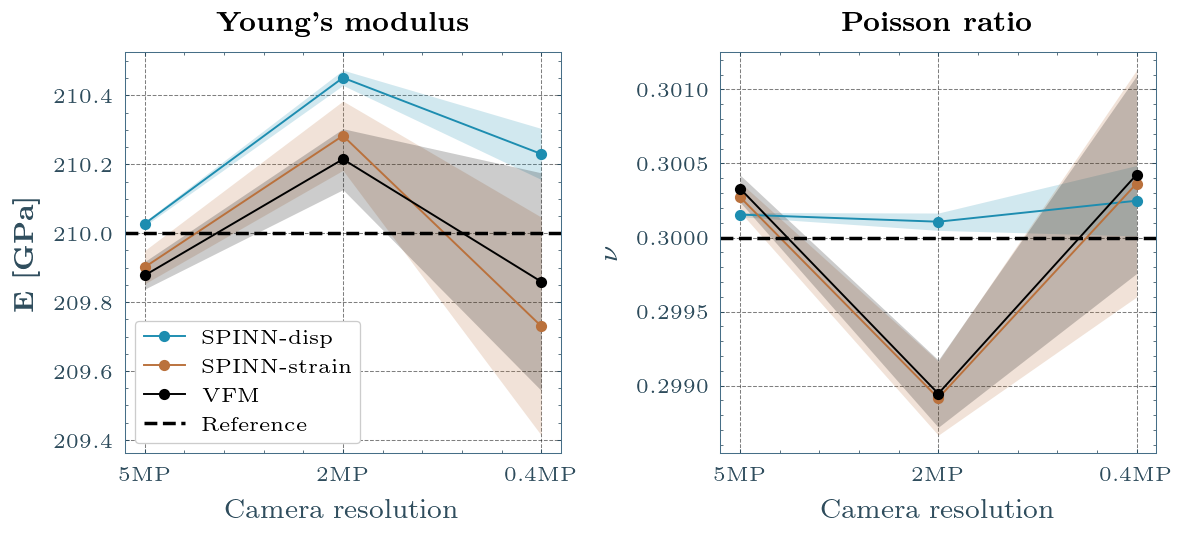

Saved: /home/r2d2/code/PhD/chapters/IV_MaterialCharacterization/01_side_loaded_plate/images/noise_study_statistics.png
Saved: /home/r2d2/code/PhD/chapters/IV_MaterialCharacterization/01_side_loaded_plate/images/pgf/noise_study_statistics.pgf


In [6]:
with open(NOISE_SUMMARY_PATH, "r") as f:
    noise_data = json.load(f)

resolutions = camera_list
x = np.arange(len(resolutions))

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(page_width, 0.45 * page_width), dpi=250, constrained_layout=True
 )
KUL_CYCLE
model_map = [
    ("SPINN-disp", "displacement", "C0"),
    ("SPINN-strain", "strain", KUL_COLORS["accent12"]),
    ("VFM", "VFM", "k"),
]

for model_label, model_key, color in model_map:
    if not all(model_key in noise_data.get(r, {}) for r in resolutions):
        continue

    E_mean = [noise_data[r][model_key]["E"]["mean"] for r in resolutions]
    E_std = [noise_data[r][model_key]["E"]["std"] for r in resolutions]
    nu_mean = [noise_data[r][model_key]["nu"]["mean"] for r in resolutions]
    nu_std = [noise_data[r][model_key]["nu"]["std"] for r in resolutions]

    ax1.plot(x, E_mean, marker="o", label=model_label, color=color)
    ax1.fill_between(x, np.array(E_mean) - np.array(E_std), np.array(E_mean) + np.array(E_std), alpha=0.2, color=color, linewidth=0)

    ax2.plot(x, nu_mean, marker="o", label=model_label, color=color)
    ax2.fill_between(x, np.array(nu_mean) - np.array(nu_std), np.array(nu_mean) + np.array(nu_std), alpha=0.2, color=color, linewidth=0)

ax1.axhline(noise_data["E_actual"], linestyle="--", linewidth=1.0, color="k", label="Reference")
ax2.axhline(noise_data["nu_actual"], linestyle="--", linewidth=1.0, color="k", label="Reference")

ax1.set_xticks(x, resolutions)
ax2.set_xticks(x, resolutions)
ax1.set_title(r"\textbf{Young's modulus}")
ax2.set_title(r"\textbf{Poisson ratio}")
ax1.set_xlabel("Camera resolution")
ax2.set_xlabel("Camera resolution")
ax1.set_ylabel(r"\textbf{E [GPa]}")
ax2.set_ylabel(r"\textbf{$\nu$}")
ax1.legend().get_frame().set_linewidth(plt_cfg().scale)
# ax2.legend().get_frame().set_linewidth(plt_cfg().scale)
# ax1.grid(True, alpha=0.3)
# ax2.grid(True, alpha=0.3)

# plt.tight_layout()
plt.show()

if save_fig:
    figure_name = "noise_study_statistics"
    fig.savefig(IMAGE_DIR / f"{figure_name}.png", bbox_inches="tight", dpi=300)
    fig.savefig(PGF_DIR / f"{figure_name}.pgf", bbox_inches="tight")
    print(f"Saved: {IMAGE_DIR / (figure_name + '.png')}")
    print(f"Saved: {PGF_DIR / (figure_name + '.pgf')}")